In [1]:
# Cell 1: Environment Setup

include("scripts/initialization_helpers.jl")
include("scripts/initialization_dictionaries.jl")
using .InitializationHelpers
using .InitializationDictionaries
using OMJulia
using Plots, DataFrames, CSV

# --- Configuration ---

# 1. Directory containing the original dynamic package
MODEL_DIR = abspath("MyIEEE14")
MODELS_PKG_PATH = joinpath(MODEL_DIR, "package.mo")

# 2. Directory containing the auxiliary package generated by BuildAux_package.ipynb
AUX_DIR = abspath("MyIEEE14_auxiliary")
AUX_PACKAGE_FILE = joinpath(AUX_DIR, "package.mo")

# 3. Root dynamic model to initialize
MODEL = "MyIEEE14.IEEE14DisconnectLine"

# 4. Derived package/model names
SOURCE_PACKAGE = split(MODEL, ".")[1]
ROOT_MODEL_NAME = split(MODEL, ".")[end]

AUX_PACKAGE = SOURCE_PACKAGE * "_auxiliary"
AUX_ROOT_MODEL = AUX_PACKAGE * "." * ROOT_MODEL_NAME * "_auxiliary"

INITIALIZED_PACKAGE = SOURCE_PACKAGE * "_initialized"
INITIALIZED_DIR = joinpath(dirname(MODEL_DIR), INITIALIZED_PACKAGE)
INITIALIZED_ROOT_MODEL = INITIALIZED_PACKAGE * "." * ROOT_MODEL_NAME * "_initialized"
INITIALIZED_PACKAGE_FILE = joinpath(INITIALIZED_DIR, "package.mo")
INITIALIZED_ORDER_FILE = joinpath(INITIALIZED_DIR, "package.order")

# 5. Output directories for OpenModelica build artifacts
RUN_OUTPUT_DIR = abspath(INITIALIZED_PACKAGE * "_outputs")
mkpath(RUN_OUTPUT_DIR)

# 6. Library paths
DYNAWO_PKG_PATH = "/home/clarafercas/Model_library/dynawo/dynawo/sources/Models/Modelica/Dynawo/package.mo"
MODELICA_PKG_PATH = "/home/clarafercas/dynawo/OpenModelica/lib/omlibrary/Modelica/package.mo"

# 7. Placeholder plot variable for the final initialized simulation
PLOT_VARIABLE = "Gen1.terminal.V.re"


"Gen1.terminal.V.re"

In [2]:
# Cell 2: OpenModelica Setup + Package Loading

# 1. Load the original dynamic package
SourceOMC = OMJulia.OMCSession()
om_send(SourceOMC, "loadFile(\"$MODELICA_PKG_PATH\")")
om_send(SourceOMC, "loadModel(Complex)")
om_send(SourceOMC, "loadModel(ModelicaServices)")
om_send(SourceOMC, "loadFile(\"$DYNAWO_PKG_PATH\")")
om_send(SourceOMC, "loadFile(\"$MODELS_PKG_PATH\")")
om_send(SourceOMC, "clearMessages()")
println("Checking the dynamic root model...")
chk_source = om_send(SourceOMC, "checkModel($MODEL)", parsed=false)
println(chk_source)

# 2. Load the auxiliary package
AuxOMC = OMJulia.OMCSession()
om_send(AuxOMC, "loadFile(\"$MODELICA_PKG_PATH\")")
om_send(AuxOMC, "loadModel(Complex)")
om_send(AuxOMC, "loadModel(ModelicaServices)")
om_send(AuxOMC, "loadFile(\"$DYNAWO_PKG_PATH\")")
om_send(AuxOMC, "loadFile(\"$AUX_PACKAGE_FILE\")")
om_send(AuxOMC, "clearMessages()")
println("Checking the auxiliary root model...")
chk_aux = om_send(AuxOMC, "checkModel($AUX_ROOT_MODEL)", parsed=false)
println(chk_aux)


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.7BrJ1rs0P1"


OMC -> loadFile("/home/clarafercas/dynawo/OpenModelica/lib/omlibrary/Modelica/package.mo")
OMC -> loadModel(Complex)
OMC -> loadModel(ModelicaServices)
OMC -> loadFile("/home/clarafercas/Model_library/dynawo/dynawo/sources/Models/Modelica/Dynawo/package.mo")
OMC -> loadFile("/home/clarafercas/dynawo-notebooks/OpenModelica_only_users/Initialization/MyIEEE14/package.mo")
OMC -> clearMessages()
Checking the dynamic root model...
OMC -> checkModel(MyIEEE14.IEEE14DisconnectLine)
"Check of MyIEEE14.IEEE14DisconnectLine completed successfully.
Class MyIEEE14.IEEE14DisconnectLine has 806 equation(s) and 806 variable(s).
308 of these are trivial equation(s)."

OMC -> loadFile("/home/clarafercas/dynawo/OpenModelica/lib/omlibrary/Modelica/package.mo")


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.LwGOsdn5lU"


OMC -> loadModel(Complex)
OMC -> loadModel(ModelicaServices)
OMC -> loadFile("/home/clarafercas/Model_library/dynawo/dynawo/sources/Models/Modelica/Dynawo/package.mo")
OMC -> loadFile("/home/clarafercas/dynawo-notebooks/OpenModelica_only_users/Initialization/MyIEEE14_auxiliary/package.mo")
OMC -> clearMessages()
Checking the auxiliary root model...
OMC -> checkModel(MyIEEE14_auxiliary.IEEE14DisconnectLine_auxiliary)
"Check of MyIEEE14_auxiliary.IEEE14DisconnectLine_auxiliary completed successfully.
Class MyIEEE14_auxiliary.IEEE14DisconnectLine_auxiliary has 875 equation(s) and 875 variable(s).
326 of these are trivial equation(s)."



In [3]:
# Cell 3: INIT Model Mapping

INIT_MODEL_BY_COMPONENT = Dict{String, String}()


Dict{String, String}()

In [4]:
# Cell 4: Inheritance Chain + Package Name Mapping

chain = get_inheritance_chain(SourceOMC, MODEL)
println("Inheritance chain:")
println(chain)

INITIALIZED_NAME_MAP = Dict(model => INITIALIZED_PACKAGE * "." * split(model, ".")[end] * "_initialized" for model in chain)


OMC -> getInheritedClasses(MyIEEE14.IEEE14DisconnectLine)
OMC -> getInheritedClasses(MyIEEE14.IEEE14Base)
Inheritance chain:
["MyIEEE14.IEEE14Base", "MyIEEE14.IEEE14DisconnectLine"]


Dict{String, String} with 2 entries:
  "MyIEEE14.IEEE14Base"           => "MyIEEE14_initialized.IEEE14Base_initializ…
  "MyIEEE14.IEEE14DisconnectLine" => "MyIEEE14_initialized.IEEE14DisconnectLine…

In [5]:
# Cell 5: Simulate Auxiliary Package + Extract Initialization Values

# Build and simulate the auxiliary root model.
ModelicaSystem(AuxOMC, AUX_PACKAGE_FILE, AUX_ROOT_MODEL, [MODELICA_PKG_PATH, DYNAWO_PKG_PATH])
simulate(AuxOMC, resultfile = AUX_PACKAGE * "_res.mat")

# Extract initialization values per original class in the inheritance chain.
initializable_by_model = Dict{String, Dict{String, Dict{String, Any}}}()
init_values_by_model = Dict{String, Dict{String, Dict{String, Float64}}}()

for model in chain
    components = get_all_components(SourceOMC, model)
    initializable_components = get_initializable_components(components, INIT_PARAMS, INIT_MODEL_BY_COMPONENT)
    init_values_by_component = extract_all_initialization_values(AuxOMC, initializable_components, INIT_PARAMS, INIT_MODEL_BY_COMPONENT)

    initializable_by_model[model] = initializable_components
    init_values_by_model[model] = init_values_by_component
end


In [6]:
# Cell 6: Build and save the initialized package
om_send(SourceOMC, "deleteClass($INITIALIZED_PACKAGE)")
om_send(SourceOMC, "clearMessages()")
om_send(SourceOMC, "loadString(\"within ; package $INITIALIZED_PACKAGE end $INITIALIZED_PACKAGE;\")")

for model in chain
    initialized_model = INITIALIZED_NAME_MAP[model]
    initialized_name = split(initialized_model, ".")[end]

    println("Copying and initializing ", model, " -> ", initialized_model)
    om_send(SourceOMC, "copyClass($model, \"$initialized_name\", $INITIALIZED_PACKAGE)")

    apply_initialization_modifiers!(
        SourceOMC,
        initialized_model,
        initializable_by_model[model],
        INIT_PARAMS,
        init_values_by_model[model],
        INIT_MODEL_BY_COMPONENT,
    )
end

mkpath(INITIALIZED_DIR)

open(INITIALIZED_PACKAGE_FILE, "w") do io
    print(io, "within ;\npackage $INITIALIZED_PACKAGE\nend $INITIALIZED_PACKAGE;\n")
end

open(INITIALIZED_ORDER_FILE, "w") do io
    for model in chain
        println(io, split(INITIALIZED_NAME_MAP[model], ".")[end])
    end
end

for model in chain
    initialized_model = INITIALIZED_NAME_MAP[model]
    initialized_name = split(initialized_model, ".")[end]
    initialized_file = joinpath(INITIALIZED_DIR, initialized_name * ".mo")

    txt = String(om_send(SourceOMC, "listFile($initialized_model)"))
    txt = rewrite_initialized_extends(txt, INITIALIZED_NAME_MAP)

    open(initialized_file, "w") do io
        print(io, txt)
        endswith(txt, "\n") || print(io, "\n")
    end
end

InitializedOMC = OMJulia.OMCSession()
om_send(InitializedOMC, "loadFile(\"$MODELICA_PKG_PATH\")")
om_send(InitializedOMC, "loadModel(Complex)")
om_send(InitializedOMC, "loadModel(ModelicaServices)")
om_send(InitializedOMC, "loadFile(\"$DYNAWO_PKG_PATH\")")
om_send(InitializedOMC, "loadFile(\"$INITIALIZED_PACKAGE_FILE\")")
om_send(InitializedOMC, "clearMessages()")
println("Checking the initialized root model...")
chk_initialized = om_send(InitializedOMC, "checkModel($INITIALIZED_ROOT_MODEL)", parsed=false)
println(chk_initialized)


OMC -> deleteClass(MyIEEE14_initialized)
OMC -> clearMessages()
OMC -> loadString("within ; package MyIEEE14_initialized end MyIEEE14_initialized;")
Copying and initializing MyIEEE14.IEEE14Base -> MyIEEE14_initialized.IEEE14Base_initialized
OMC -> copyClass(MyIEEE14.IEEE14Base, "IEEE14Base_initialized", MyIEEE14_initialized)
OMC -> updateComponent(Gen2, Dynawo.Electrical.Machines.SignalN.GeneratorPV, MyIEEE14_initialized.IEEE14Base_initialized, modification = $Code((PNom = 1008, QGen0Pu = 0.43722556877746155, u0Pu = Complex(1.041121504941116, -0.09078269181482627), i0Pu = Complex(-0.3449592973139179, 0.45003575483792346), UDeadBandPu = 1e-4, U0Pu = 1.045072, URef0Pu = 1.045072, limUQUp0 = false, limUQDown0 = false, PGen0Pu = 0.4, QDeadBandPu = 1e-4, PMaxPu = 10.08, QMinPu = -100, KGover = 1, qStatus0 = Dynawo.Electrical.Machines.SignalN.GeneratorPV.QStatus.Standard, PMinPu = 0, PRef0Pu = -0.4, QMaxPu = 100, QNomAlt = 10000)))
OMC -> updateComponent(Gen6, Dynawo.Electrical.Machines.Sign

[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.tiXDPMZZMk"


OMC -> loadModel(Complex)
OMC -> loadModel(ModelicaServices)
OMC -> loadFile("/home/clarafercas/Model_library/dynawo/dynawo/sources/Models/Modelica/Dynawo/package.mo")
OMC -> loadFile("/home/clarafercas/dynawo-notebooks/OpenModelica_only_users/Initialization/MyIEEE14_initialized/package.mo")
OMC -> clearMessages()
Checking the initialized root model...
OMC -> checkModel(MyIEEE14_initialized.IEEE14DisconnectLine_initialized)
"Check of MyIEEE14_initialized.IEEE14DisconnectLine_initialized completed successfully.
Class MyIEEE14_initialized.IEEE14DisconnectLine_initialized has 806 equation(s) and 806 variable(s).
308 of these are trivial equation(s)."



In [7]:
# Cell 7: Final simulation of the initialized package

om_send(InitializedOMC, "clearMessages()")

ModelicaSystem(
    InitializedOMC,
    INITIALIZED_PACKAGE_FILE,
    INITIALIZED_ROOT_MODEL,
    [MODELICA_PKG_PATH, DYNAWO_PKG_PATH],
    customBuildDirectory = RUN_OUTPUT_DIR,
)

initialized_resultfile_name = INITIALIZED_PACKAGE * "_res.csv"
simulate(InitializedOMC, resultfile = initialized_resultfile_name, simflags = "-outputFormat=csv")
initialized_resultfile = joinpath(getWorkDirectory(InitializedOMC), initialized_resultfile_name)


OMC -> clearMessages()


"/home/clarafercas/dynawo-notebooks/OpenModelica_only_users/Initialization/MyIEEE14_initialized_outputs/MyIEEE14_initialized_res.csv"

WebIO._IJuliaInit()

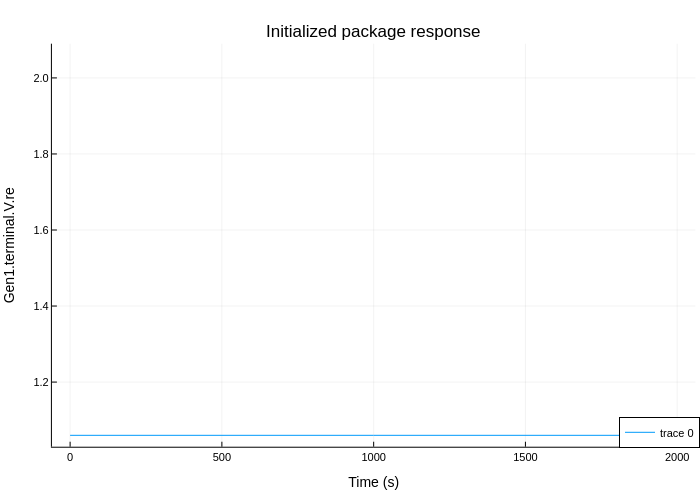

In [8]:
# Cell 8: Plot the initialized package response

initialized_df = DataFrame(CSV.File(initialized_resultfile; select = ["time", PLOT_VARIABLE]))

plotlyjs()
p = plot(initialized_df[!, "time"], initialized_df[!, PLOT_VARIABLE], label = [PLOT_VARIABLE])
plot!(p, legend = :bottomright, titlefontsize = 12, labelfontsize = 10)
title!(p, "Initialized package response")
xlabel!(p, "Time (s)")
ylabel!(p, PLOT_VARIABLE)


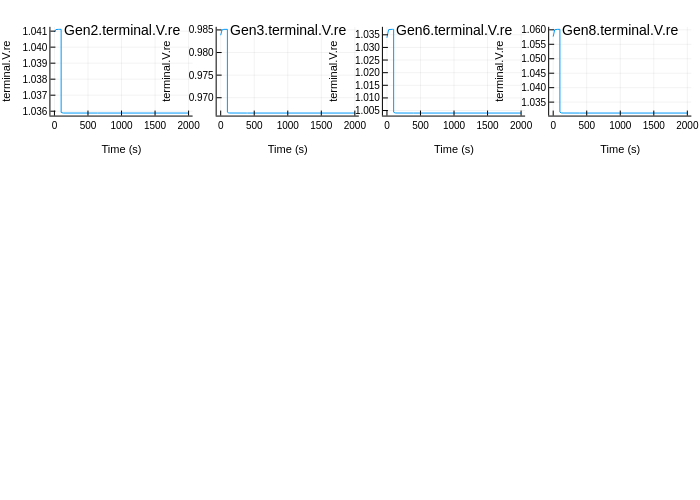

In [9]:
# Cell 9: Plot the other generator voltages

plot_generator = split(PLOT_VARIABLE, ".")[1]
voltage_suffix = join(split(PLOT_VARIABLE, ".")[2:end], ".")
all_generators = ["Gen1", "Gen2", "Gen3", "Gen6", "Gen8"]
other_generators = [generator for generator in all_generators if generator != plot_generator]
other_voltage_variables = [generator * "." * voltage_suffix for generator in other_generators]

other_initialized_df = DataFrame(CSV.File(initialized_resultfile; select = vcat(["time"], other_voltage_variables)))

plotlyjs()
other_voltage_plots = Any[]
for variable in other_voltage_variables
    p_single = plot(
        other_initialized_df[!, "time"],
        other_initialized_df[!, variable],
        label = false,
        title = variable,
        xlabel = "Time (s)",
        ylabel = voltage_suffix,
        titlefontsize = 10,
        guidefontsize = 8,
        tickfontsize = 7,
    )
    push!(other_voltage_plots, p_single)
end
plot(other_voltage_plots..., layout = (5, 4), size = (1600, 1200))


In [10]:
# Cell 10: OMC diagnostics for failed initialized simulation

# Run this cell after the final simulation cell fails.

#=
println("=== Initialized package OMC diagnostics start ===")

if isdefined(Main, :InitializedOMC)
    print_omc_errors(InitializedOMC, "after failed final simulation cell")
end

DiagnosticOMC = OMJulia.OMCSession()
om_send(DiagnosticOMC, "loadFile(\"$MODELICA_PKG_PATH\")")
om_send(DiagnosticOMC, "loadModel(Complex)")
om_send(DiagnosticOMC, "loadModel(ModelicaServices)")
om_send(DiagnosticOMC, "loadFile(\"$DYNAWO_PKG_PATH\")")
om_send(DiagnosticOMC, "loadFile(\"$INITIALIZED_PACKAGE_FILE\")")
om_send(DiagnosticOMC, "cd(\"$RUN_OUTPUT_DIR\")")
print_omc_errors(DiagnosticOMC, "after loading initialized package")

run_omc_diagnostic(DiagnosticOMC, "checkModel($INITIALIZED_ROOT_MODEL)", "checkModel($INITIALIZED_ROOT_MODEL)")

if isdefined(Main, :chain) && isdefined(Main, :INITIALIZED_NAME_MAP)
    for model in chain
        initialized_model = INITIALIZED_NAME_MAP[model]
        run_omc_diagnostic(DiagnosticOMC, "checkModel($initialized_model)", "checkModel($initialized_model)")
    end
end

run_omc_diagnostic(DiagnosticOMC, "instantiateModel($INITIALIZED_ROOT_MODEL)", "instantiateModel($INITIALIZED_ROOT_MODEL)")
run_omc_diagnostic(DiagnosticOMC, "buildModel($INITIALIZED_ROOT_MODEL)", "buildModel($INITIALIZED_ROOT_MODEL)")

println("=== Initialized package OMC diagnostics end ===")
=#
